In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from keras.preprocessing import image
from tensorflow. keras.utils import img_to_array, array_to_img
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dropout, Dense
from sklearn. model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
'train',
labels="inferred",
label_mode="categorical",
class_names=None,
color_mode="rgb",
batch_size=32,
image_size=(256, 256),
shuffle=True,
seed=None,
validation_split=None,
subset=None,
interpolation="bilinear",
follow_links=False,
crop_to_aspect_ratio=False,
)

Found 70296 files belonging to 38 classes.


In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
'valid',
labels="inferred",
label_mode="categorical",
class_names=None,
color_mode="rgb",
batch_size=32,
image_size=(128, 128),
shuffle=True,
seed=None,
validation_split=None,
subset=None,
interpolation="bilinear",
follow_links=False,
crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[187. 186. 194.]
   [186. 185. 193.]
   [186. 185. 193.]
   ...
   [129. 123. 127.]
   [133. 127. 131.]
   [135. 129. 133.]]

  [[184. 183. 191.]
   [184. 183. 191.]
   [185. 184. 192.]
   ...
   [135. 129. 133.]
   [129. 123. 127.]
   [126. 120. 124.]]

  [[182. 181. 189.]
   [183. 182. 190.]
   [184. 183. 191.]
   ...
   [134. 128. 132.]
   [128. 122. 126.]
   [124. 118. 122.]]

  ...

  [[175. 174. 182.]
   [175. 174. 182.]
   [178. 177. 185.]
   ...
   [140. 135. 141.]
   [137. 132. 138.]
   [132. 127. 133.]]

  [[173. 172. 180.]
   [175. 174. 182.]
   [178. 177. 185.]
   ...
   [140. 135. 141.]
   [141. 136. 142.]
   [140. 135. 141.]]

  [[176. 175. 183.]
   [181. 180. 188.]
   [186. 185. 193.]
   ...
   [134. 129. 135.]
   [136. 131. 137.]
   [136. 131. 137.]]]


 [[[163. 153. 152.]
   [165. 155. 154.]
   [167. 157. 156.]
   ...
   [177. 170. 177.]
   [179. 172. 179.]
   [179. 172. 179.]]

  [[167. 157. 156.]
   [168. 158. 157.]
   [169. 159. 158.]
   ...
   [172. 1

In [11]:
##Building Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten ,Dropout
from tensorflow.keras.models import Sequential

In [12]:
model=Sequential()

In [13]:
## Building Convolution Layer

In [14]:
model.add(Conv2D(filters=32, kernel_size=3, padding ='same', activation='relu', input_shape=[128, 128,3]))
model.add(Conv2D(filters=32, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [15]:
model.add(Conv2D(filters=64, kernel_size=3, padding ='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [16]:
model.add(Conv2D(filters=128, kernel_size=3, padding ='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [17]:
model.add(Conv2D(filters=256, kernel_size=3, padding ='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [18]:
model.add(Conv2D(filters=512, kernel_size=3, padding ='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [19]:
model.add(Dropout(0.25)) #To avoid overfitting

In [20]:
model.add(Flatten())
model.add(Dense(units=1500, activation='relu'))

In [21]:
model.add(Dropout(0.4))
#Output Layer
model.add(Dense(units=38,activation='softmax'))

In [22]:
##Compiling Model
model.compile(optimizer=tf.keras.optimizers.Adam(
     learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
model.summary()
Model: "sequential_1"

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
print(x.shape)
print(y.shape)

(32, 256, 256, 3)
(32, 38)


In [25]:
import os
print(os.getcwd())


C:\Users\KIIT0001\Desktop\Plant disease detection


In [26]:
import os

print(os.path.exists(r'C:\Users\KIIT0001\Desktop\Plant disease detection'))
print(os.path.exists(r'C:\Users\KIIT0001\Desktop\Plant disease detection\training_set'))


True
False


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For training data
train_datagen = ImageDataGenerator(rescale=1./255)

# For validation/test data
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\Plant disease detection\train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

validation_set = test_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\Plant disease detection\valid',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)


Found 70296 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [28]:
training_set = train_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\Plant disease detection\train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

validation_set = test_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\Plant disease detection\valid',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)


Found 70296 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [29]:
os.chdir(r'C:\Users\KIIT0001\Desktop\Plant disease detection')

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data generators
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training data
training_set = train_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\Plant disease detection\train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

# Validation data
validation_set = test_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\Plant disease detection\valid',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)


Found 70296 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [31]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3), padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [32]:
target_size=(128, 128)

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3), padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [34]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10,
    batch_size=32
)

C:\Users\KIIT0001\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1755s 798ms/step - accuracy: 0.0283 - loss: -10879079146323968.0000 - val_accuracy: 0.0283 - val_loss: -59071665929191424.0000
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 256s 117ms/step - accuracy: 0.0283 - loss: -391293167300771840.0000 - val_accuracy: 0.0283 - val_loss: -1007331115523899392.0000
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 288s 131ms/step - accuracy: 0.0283 - loss: -2569617772862504960.0000 - val_accuracy: 0.0283 - val_loss: -4816308980647198720.0000
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 297s 135ms/step - accuracy: 0.0283 - loss: -8990353637091835904.0000 - val_accuracy: 0.0283 - val_loss: -14428130229258027008.0000
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 309s 140ms/step - accuracy: 0.0283 - loss: -23152908927288475648.0000 - val_accuracy: 0.0283 - val_loss: -33901296994798796800.0000
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 311s 142ms/step - accuracy: 0.0283 - loss: -49760822038630498304.0000 - val_accuracy: 0.0283 - val_

In [35]:
print(training_set.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3), padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [39]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 180s 82ms/step - accuracy: 0.0283 - loss: -11256626098995200.0000 - val_accuracy: 0.0283 - val_loss: -61504258096234496.0000
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 284s 129ms/step - accuracy: 0.0283 - loss: -406725294032945152.0000 - val_accuracy: 0.0283 - val_loss: -1048261054343151616.0000
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 217s 99ms/step - accuracy: 0.0283 - loss: -2671871529611952128.0000 - val_accuracy: 0.0283 - val_loss: -5018014388762705920.0000
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 218s 99ms/step - accuracy: 0.0283 - loss: -9390891429439471616.0000 - val_accuracy: 0.0283 - val_loss: -15070342876414083072.0000
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 239s 109ms/step - accuracy: 0.0283 - loss: -24175602075678277632.0000 - val_accuracy: 0.0283 - val_loss: -35416652716292702208.0000
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 193s 88ms/step - accuracy: 0.0283 - loss: -51990869114271825920.0000 - val_accuracy: 0.0283 - val_loss:

In [40]:
##Model Evalution
#Model Evaluation on Training set
train_loss, train_acc= model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.0283 - loss: -543290544779188764672.0000


In [41]:
##Model Evaluation on Training set
train_loss, train_acc= model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 87s 40ms/step - accuracy: 0.0283 - loss: -543289876276119076864.0000


In [42]:
 print(train_loss,train_acc)

-5.432898762761191e+20 0.028266187757253647


In [43]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.0283 - loss: -542991899828898758656.0000


In [44]:
 print(val_loss,val_acc)

-5.4299189982889876e+20 0.028283633291721344


In [45]:
model.save("trained_model.keras")

In [46]:
training_history.history

{'accuracy': [0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647,
  0.028266187757253647],
 'loss': [-1.12566260989952e+16,
  -4.0672529403294515e+17,
  -2.671871529611952e+18,
  -9.390891429439472e+18,
  -2.4175602075678278e+19,
  -5.199086911427183e+19,
  -9.918086584139461e+19,
  -1.735316101263052e+20,
  -2.8481012093314243e+20,
  -4.442891104393542e+20],
 'val_accuracy': [0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344,
  0.028283633291721344],
 'val_loss': [-6.15042580962345e+16,
  -1.0482610543431516e+18,
  -5.018014388762706e+18,
  -1.5070342876414083e+19,
  -3.5416652716292702e+19,
  -7.171531606820127e+19,
  -1.3109417324540697e+20,
  -2.2201759241299454e

In [47]:
#Recording History in Json
import json
with open("training_hist.json", "w") as f:
    json.dump (training_history.history, f)

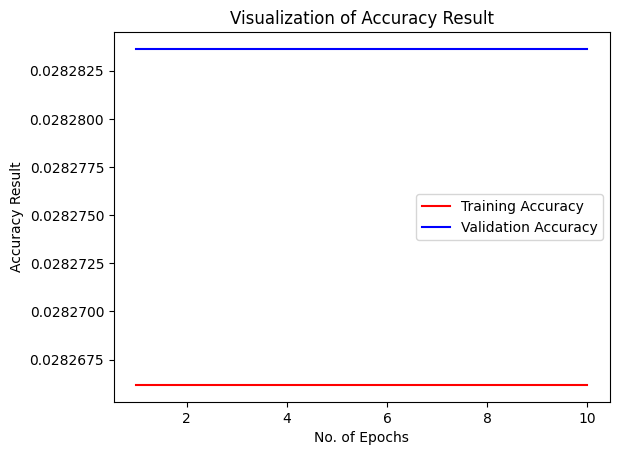

In [48]:
##Accuracy Visualization
epochs = [i for i in range(1,11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'],color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [49]:
class_name = list(validation_set.class_indices.keys())
print(class_name)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [50]:
test_set = tf.keras.utils.image_dataset_from_directory(
'valid',
labels="inferred",
label_mode="categorical",
class_names=None, 
color_mode="rgb",
batch_size=32,
image_size=(128, 128),
shuffle=False,
seed=None,
validation_split=None,
subset=None,
interpolation="bilinear",
follow_links=False,
crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [51]:
import os
os.getcwd()

'C:\\Users\\KIIT0001\\Desktop\\Plant disease detection'

In [52]:
test_set = train_datagen.flow_from_directory(
    r'C:\Users\KIIT0001\Desktop\\Plant disease detection\train',  # full path here
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 70296 images belonging to 38 classes.


In [53]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory(
    r'C:\\Users\\KIIT0001\\Desktop\\Plant disease detection',   
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False               
)

Found 87906 images belonging to 4 classes.


In [55]:
y_pred = model.predict(test_set)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_6" is incompatible with the layer: expected axis -1 of input shape to have value 8192, but received input with shape (32, 32768)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 128, 128, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [56]:
y_pred = model.predict(test_set)
print("Prediction shape:", y_pred.shape)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_6" is incompatible with the layer: expected axis -1 of input shape to have value 8192, but received input with shape (32, 32768)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 128, 128, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [57]:
predicted_categories = tf.argmax(y_pred, axis=1)

NameError: name 'y_pred' is not defined

In [58]:
predicted_categories

NameError: name 'predicted_categories' is not defined

In [ ]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

In [ ]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,predicted_categories, target_names=class_name))

In [ ]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

In [ ]:
##
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True, annot_kws={'size':10})
plt.xlabel("Predicted Class", fontsize=20)
plt.ylabel("Actual Class", fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize=25)
plt.show()